# Causal Inference Project - Billboard Impact

This notebook evaluates whether placing three billboards in Porto Alegre during June increased savings account deposits by comparing Porto Alegre (treatment) to Florianopolis (control). We use a difference-in-differences design to estimate the treatment effect, check the parallel-trends assumption, and run basic robustness checks.

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf

In [4]:
data = pd.read_csv("data/billboard_impact.csv")
data.head()

,deposits,poa,jul
0,42,1,0
1,0,1,0
2,52,1,0
3,119,1,0
4,21,1,0


Variables:
- deposits is the outcome variable.
- poa is the dummy variable for Porto Alegre. 0 means samples are from Florianopolis. 
- jul is the dummy variable for July. 0 means samples are from May, pre-intervention period.

## Difference-in-Differences

The causal effect is the outcome in the period post intervention in case of a treatment minus the outcome in also in the period after the intervention, but in the case of no treatment. However, we can’t measure this because the ladder would be counterfactual.

One way around this is a before and after comparasion. This means comparing the average deposits from POA before and after the billboard was placed.

In [5]:
poa_before = data.query("poa==1 & jul==0")["deposits"].mean()

poa_after = data.query("poa==1 & jul==1")["deposits"].mean()

poa_after - poa_before

41.04775

This estimator is telling us that we should expect deposits to increase $41.04 after the intervention.

However, this estimator is assuming that in the case of no intervention, the outcome in the latter period would be the same as the outcome from the starting period. This would be false if the outcome variable follow a trend. If deposits are going up in POA, then the outcome of the latter period would be greater than that of the starting period even without the intervention and vice versa. So this is not a good estimator.

Another idea is to compare the treated group with an untreated group that didn't get the intervention. This would be comparing the deposits from POA and from Florianopolis in the post intervention period.

In [6]:
fl_after = data.query("poa==0 & jul==1")["deposits"].mean()
poa_after - fl_after

-119.10175000000001

This estimator is telling us that customers will decrease deposits by $119.10 after the intervention. 

However in this estimator we are assuming that both groups have the same baseline. This is also not a good estimator. 

Now we will try to use diff-in-diff estimator.  The idea behind is that the treated after the intervention, had it not been treated, would look like the treated before the treatment plus a growth factor that is the same as the growth of the control. It gets the name because it is the difference between the difference between treatment and control after and before the treatment. 

In [7]:
fl_before = data.query("poa==0 & jul==0")["deposits"].mean()

diff_in_diff = (poa_after-poa_before)-(fl_after-fl_before)
diff_in_diff

6.524557692307688

This estimator is telling us that we should expect deposits to increase by $6.52 per customer. It just assumes that the growth pattern between the 2 cities are the same, but it does not require a similar baseline nor a zero trend.

We can visualize diff-in-diff by projecting the growth trend from the untreated into the treated to see the counterfactual, which is the number of deposits we should expect if there were no intervention. 

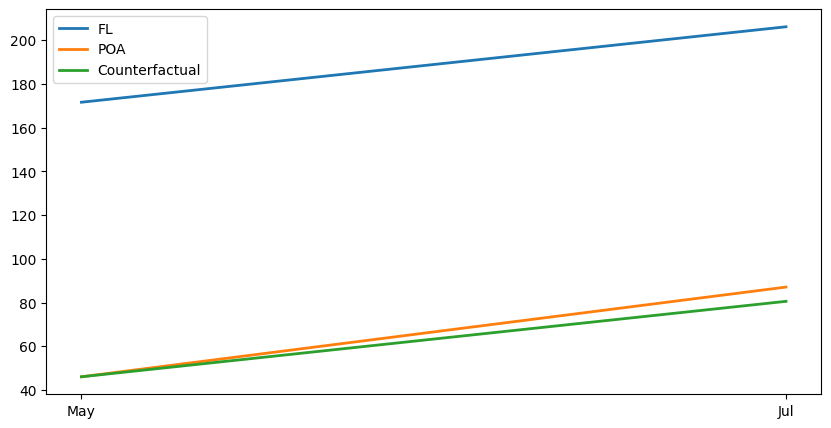

In [9]:
plt.figure(figsize=(10,5))
plt.plot(["May", "Jul"], [fl_before, fl_after], label="FL", lw=2)
plt.plot(["May", "Jul"], [poa_before, poa_after], label="POA", lw=2)

plt.plot(["May", "Jul"], [poa_before, poa_before+(fl_after-fl_before)],
         label="Counterfactual", lw=2, color="C2")

plt.legend();

The small difference between the green and orange lines is representing the treatment effect on Porto Alegre.

We can get standard errors by fitting a linear model with the interaction term between the two variables. 

In [10]:
smf.ols('deposits ~ poa*jul', data=data).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,171.6423,2.363,72.625,0.000,167.009,176.276
poa,-125.6263,4.484,-28.015,0.000,-134.418,-116.835
jul,34.5232,3.036,11.372,0.000,28.571,40.475
poa:jul,6.5246,5.729,1.139,0.255,-4.706,17.755


The interaction term has the same value as the diff-in-diff estimator and now we have the standard erro to check if its statistically significant. 

One problem with diff-in-diff is that if the growth trend from the treated is different from the trend of the control then diff-in-diff will be biased. So if the decision to treat a region is based on its potential to respond to the treatment then this will make it harder for diff-in-diff to be reliable. For example, sales perform poorly in Porto Alegre so the growth we would see there without a billboard would be lower than the growth we observe in other cities. This would cause us to underestimate the effect of the billboard there. 